# 8. Engagement Analysis


> **Dataset note:** This project uses a synthetic OTT viewer-behaviour dataset for educational analysis.  
> **Hotstar is used only as the business case/scenario; the data is not claimed to be proprietary Hotstar data.**

**Allowed tools:** Python, NumPy, Pandas, Matplotlib, Seaborn.  
**Not used:** Scikit-learn, Plotly, Power BI, Tableau, machine learning, or statistical libraries beyond NumPy/Pandas.

## Process Performed
I created the engagement score from the brief, ranked episodes, compared genres, analyzed hook/pacing relationships, and identified consistently strong shows.

In [1]:
# PROCESS: Load the CSV into a Pandas DataFrame and verify that the file loaded correctly.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

DATA_PATH = "ott_viewer_dropoff_retention_us_v1.0.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (33171, 23)


,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,dialogue_density,visual_intensity,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk,dataset_version
0,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,1,48,4,5,high,5,39,3,0,0,9,high,0,1,0.649,high,v1.0
1,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,2,55,5,4,low,8,55,3,3,1,5,medium,0,0,0.473,medium,v1.0
2,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,3,51,4,8,high,7,46,4,2,0,9,high,0,0,0.583,medium,v1.0
3,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,4,50,4,7,medium,3,50,4,1,0,7,high,0,0,0.520,medium,v1.0
4,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,5,52,4,3,low,4,35,3,0,1,7,high,0,1,0.638,high,v1.0


## Create Engagement Score

The formula below follows the example given in the project brief.

In [2]:
# KERNEL-SAFE SETUP
# Keep plotting memory controlled while preserving the analysis.
import gc

MAX_PLOT_ROWS = 5000

def safe_sample(data, n=MAX_PLOT_ROWS, random_state=42):
    """Use the full data when small; otherwise use a reproducible sample for plotting."""
    return data if len(data) <= n else data.sample(n=n, random_state=random_state)

def finish_plot():
    """Render and release the current Matplotlib figure."""
    plt.tight_layout()
    plt.show()
    plt.close()
    gc.collect()

## Why This Engagement Score Is Used

The engagement score is a **project-defined composite metric**, not a scientifically validated industry standard. It combines four signals available in the supplied brief:

- `avg_watch_percentage` — direct completion/consumption signal.
- `hook_strength` — strength of the opening.
- `pacing_score` — perceived pacing quality.
- `visual_intensity` — visual stimulation.

The 1–10 content scores are multiplied by 5 so they contribute on a scale closer to watch percentage before combination. The formula is useful for this EDA because it creates one consistent ranking metric, but recommendations should still be checked against watch percentage, drop-off probability, and retention risk separately.

In [3]:
# PROCESS: Create the project-defined engagement score before ranking or grouping content.
# Engagement score based on the formula provided in the project brief.
# Watch percentage is already on a 0-100 scale, while the 1-10 content scores
# are multiplied by 5 before combining them.
df["engagement_score"] = (
    df["avg_watch_percentage"]
    + df["hook_strength"] * 5
    + df["pacing_score"] * 5
    + df["visual_intensity"] * 5
) / 2

df["engagement_score"].describe()

count    33171.000000
mean        70.734135
std         12.023213
min         30.000000
25%         62.500000
50%         71.000000
75%         79.500000
max        117.500000
Name: engagement_score, dtype: float64

## Highest-Engagement Episodes

In [4]:
# PROCESS: Create the project-defined engagement score before ranking or grouping content.
top_engagement = (
    df.sort_values("engagement_score", ascending=False)
    [["title", "season_number", "episode_number", "genre",
      "avg_watch_percentage", "hook_strength", "pacing_score",
      "visual_intensity", "engagement_score"]]
    .head(10)
)
display(top_engagement)

,title,season_number,episode_number,genre,avg_watch_percentage,hook_strength,pacing_score,visual_intensity,engagement_score
16149,30 Rock,1,1,Comedy,100,10,8,9,117.5
1840,Young Sheldon,1,1,Comedy,99,10,8,8,114.5
13312,Buffy the Vampire Slayer,1,1,Sci-Fi & Fantasy,98,10,7,8,111.5
7315,The Late Show with Stephen Colbert,1,12,Comedy,94,8,8,9,109.5
1408,Tagesschau,1,1,News,86,10,7,9,108.0
1198,Arrow,1,1,Crime,85,10,7,9,107.5
27533,Good Mythical Morning,1,50,Comedy,89,8,8,9,107.0
33099,The Cosby Show,1,6,Comedy,89,8,8,9,107.0
2342,Running Man,1,244,Comedy,88,8,8,9,106.5
197,Law & Order,1,1,Crime,98,10,7,6,106.5


## Engagement by Genre

,genre,engagement_score
2,Comedy,77.382784
9,News,74.554348
4,Documentary,72.593333
3,Crime,71.687365
6,Family,71.514423
11,Sci-Fi & Fantasy,71.234321
12,Soap,71.220060
1,Animation,71.084563
7,Kids,71.068038
13,Talk,71.042671


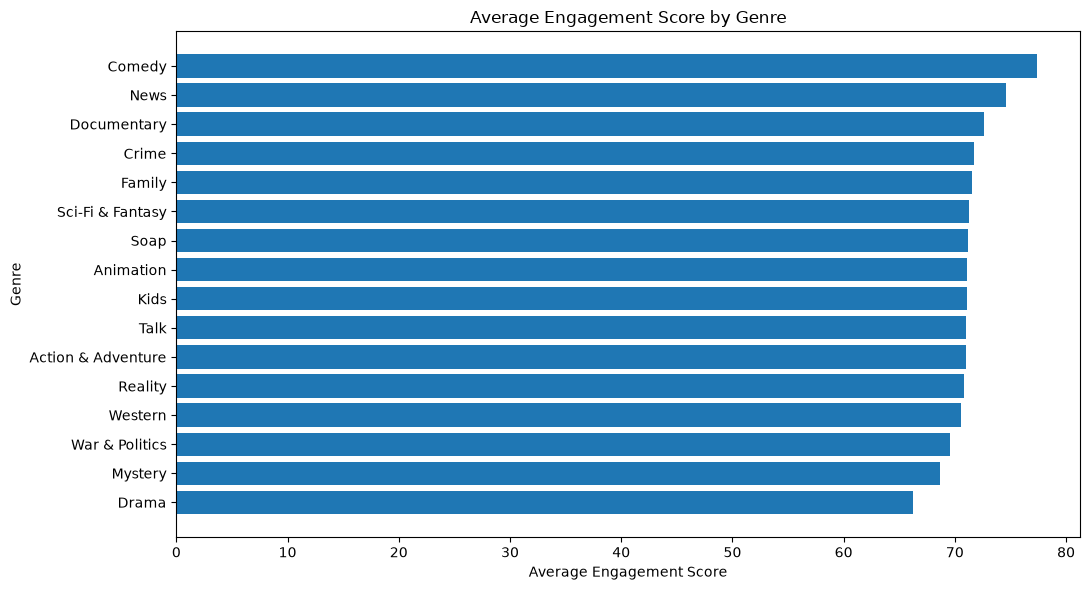

In [5]:
# PROCESS: Compare the project-defined engagement score across genres.
genre_engagement = (
    df.groupby("genre", as_index=False)["engagement_score"]
    .mean()
    .sort_values("engagement_score", ascending=False)
)

display(genre_engagement)

# Use a horizontal bar chart so all genre names remain readable.
plot_data = genre_engagement.sort_values("engagement_score", ascending=True)

plt.figure(figsize=(11, 6))
plt.barh(plot_data["genre"], plot_data["engagement_score"])
plt.title("Average Engagement Score by Genre")
plt.xlabel("Average Engagement Score")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()
plt.close()

## Hook Strength and Engagement

In [6]:
# PROCESS: Create the project-defined engagement score before ranking or grouping content.
hook_engagement = df.groupby("hook_strength", as_index=False).agg(
    avg_watch_percentage=("avg_watch_percentage", "mean"),
    avg_engagement_score=("engagement_score", "mean"),
    episodes=("show_id", "size")
)
display(hook_engagement)

,hook_strength,avg_watch_percentage,avg_engagement_score,episodes
0,3,46.656029,59.385585,5515
1,4,50.800921,63.993002,5430
2,5,54.569292,68.396517,5484
3,6,58.658223,72.658580,5606
4,7,62.740734,77.474922,5423
5,8,66.833725,81.862674,5527
6,9,70.397590,85.469880,83
7,10,73.543689,89.538835,103


## Pacing and Engagement

In [7]:
# PROCESS: Create the project-defined engagement score before ranking or grouping content.
pacing_engagement = df.groupby("pacing_score", as_index=False).agg(
    avg_watch_percentage=("avg_watch_percentage", "mean"),
    avg_engagement_score=("engagement_score", "mean"),
    episodes=("show_id", "size")
)
display(pacing_engagement)

,pacing_score,avg_watch_percentage,avg_engagement_score,episodes
0,3,42.236774,57.531290,1550
1,4,45.148902,61.406109,7562
2,5,58.251439,70.413789,8340
3,6,61.393037,74.647224,8358
4,7,64.096505,78.256839,6580
5,8,72.632522,85.419974,781


## Shows with Consistently High Engagement

In [8]:
# PROCESS: Summarize show engagement using show_id + title so identical titles are not merged.
show_engagement = (
    df.groupby(["show_id", "title"])
    .agg(
        episodes=("episode_number", "size"),
        avg_engagement=("engagement_score", "mean"),
        std_engagement=("engagement_score", "std"),
        avg_watch=("avg_watch_percentage", "mean")
    )
    .reset_index()
)

# "Consistently high" is operationalized as high mean engagement with
# enough episode observations to avoid tiny-sample rankings.
min_episodes = max(5, int(show_engagement["episodes"].median()))
consistent = (
    show_engagement[show_engagement["episodes"] >= min_episodes]
    .sort_values(["avg_engagement", "std_engagement"], ascending=[False, True])
    .head(15)
)
display(consistent)

,show_id,title,episodes,avg_engagement,std_engagement,avg_watch
140,4608,30 Rock,21,81.071429,12.743906,65.952381
303,71728,Young Sheldon,22,81.000000,11.315813,69.045455
30,1100,How I Met Your Mother,22,80.886364,10.711511,66.545455
130,4454,Will & Grace,22,80.750000,11.267051,68.318182
372,112888,True Beauty,16,80.031250,10.835849,66.312500
129,4419,Real Time with Bill Maher,20,80.000000,11.813240,66.250000
211,39340,2 Broke Girls,24,79.979167,9.369793,66.625000
237,48891,Brooklyn Nine-Nine,22,79.500000,8.980137,67.181818
159,10536,The Mike Douglas Show,36,79.277778,10.884750,65.500000
249,59941,The Tonight Show Starring Jimmy Fallon,191,79.222513,11.370968,66.010471


### Interpretation Note
The outputs above describe patterns in the supplied **synthetic episode-level dataset**. They should support business hypotheses and content investigation, not be presented as causal proof or proprietary Hotstar findings.

### Engagement Interpretation

The strongest engagement pattern is not driven by one variable alone. In this dataset, higher hook strength and pacing are positively associated with engagement, while the most highly engaged records also show higher watch completion and lower drop-off probability. This supports using the composite score for ranking, but not as the only decision criterion.

## Engagement Metric — Interpretation and Normalization

The project brief provides a composite `engagement_score` formula as an example.  
For assignment compatibility, the original formula is retained. However, it should be interpreted as an **engagement index**, not a percentage or probability, because its theoretical range can exceed 100.

A second `normalized_engagement_score` is added on a 0–100 style scale for easier communication. This normalized score is still a custom exploratory metric, not a scientifically validated measurement.

In [9]:
# Assignment-defined composite index.
df["engagement_index"] = (
    df["avg_watch_percentage"]
    + df["hook_strength"] * 5
    + df["pacing_score"] * 5
    + df["visual_intensity"] * 5
) / 2

# Keep the original column name for compatibility with the assignment brief.
df["engagement_score"] = df["engagement_index"]

# Optional 0–100 style normalized composite for easier business communication.
# Each 1–10 content score is converted approximately to a 0–100 scale first.
df["normalized_engagement_score"] = (
    df["avg_watch_percentage"] * 0.40
    + (df["hook_strength"] * 10) * 0.20
    + (df["pacing_score"] * 10) * 0.20
    + (df["visual_intensity"] * 10) * 0.20
)

display(
    df[["engagement_index", "normalized_engagement_score"]]
    .describe()
    .round(2)
)

,engagement_index,normalized_engagement_score
count,33171.00,33171.00
mean,70.73,56.59
std,12.02,9.62
min,30.00,24.00
25%,62.50,50.00
50%,71.00,56.80
75%,79.50,63.60
max,117.50,94.00


## Genre Engagement with Sample Size and Robust Statistics

Genre rankings should be interpreted together with the number of episode observations.  
Median and standard deviation are included so a high average is not mistaken for consistent performance.

In [10]:
genre_engagement_rigorous = (
    df.groupby("genre")
    .agg(
        episodes=("episode_number", "count"),
        avg_watch=("avg_watch_percentage", "mean"),
        median_watch=("avg_watch_percentage", "median"),
        avg_engagement=("engagement_index", "mean"),
        median_engagement=("engagement_index", "median"),
        engagement_std=("engagement_index", "std"),
        drop_off_rate=("drop_off", "mean")
    )
    .sort_values("avg_engagement", ascending=False)
)

genre_engagement_rigorous["drop_off_rate_pct"] = (
    genre_engagement_rigorous["drop_off_rate"] * 100
)

display(genre_engagement_rigorous.round(2))

,episodes,avg_watch,median_watch,avg_engagement,median_engagement,engagement_std,drop_off_rate,drop_off_rate_pct
genre,,,,,,,,
Comedy,3067,64.29,64.0,77.38,77.50,11.10,0.03,2.87
News,46,61.83,61.5,74.55,74.50,12.04,0.04,4.35
Documentary,75,57.25,60.0,72.59,73.50,12.36,0.17,17.33
Crime,926,57.22,58.0,71.69,72.00,12.55,0.16,15.87
Family,208,56.71,57.0,71.51,71.75,11.55,0.13,12.98
Sci-Fi & Fantasy,574,57.43,58.0,71.23,71.50,11.96,0.13,13.07
Soap,334,57.23,57.5,71.22,70.25,12.03,0.13,13.17
Animation,10028,57.11,58.0,71.08,71.50,11.65,0.13,13.48
Kids,632,56.65,57.0,71.07,71.75,11.77,0.12,11.87


## Show-Level Scorecard

To identify consistently strong shows, each show is summarized using episode count, average/median watch completion, average engagement, engagement variability, and drop-off risk.

In [11]:
# PROCESS: Build a show-level scorecard without merging different shows that share a title.
# Group by show_id + title so different shows with the same title are not merged.
show_scorecard = (
    df.groupby(["show_id", "title"])
    .agg(
        episodes=("episode_number", "count"),
        avg_watch=("avg_watch_percentage", "mean"),
        median_watch=("avg_watch_percentage", "median"),
        avg_engagement=("engagement_index", "mean"),
        median_engagement=("engagement_index", "median"),
        engagement_variability=("engagement_index", "std"),
        avg_drop_probability=("drop_off_probability", "mean"),
        drop_off_rate=("drop_off", "mean")
    )
    .reset_index()
)

show_scorecard["drop_off_rate_pct"] = show_scorecard["drop_off_rate"] * 100

# Apply a minimum sample-size rule before ranking shows.
reliable_shows = show_scorecard[show_scorecard["episodes"] >= 10].copy()

display(
    reliable_shows
    .sort_values(
        ["avg_engagement", "engagement_variability"],
        ascending=[False, True]
    )
    .head(20)
    .round(2)
)

,show_id,title,episodes,avg_watch,median_watch,avg_engagement,median_engagement,engagement_variability,avg_drop_probability,drop_off_rate,drop_off_rate_pct
32,1215,Californication,12,71.92,73.0,83.67,84.50,6.81,0.36,0.00,0.00
132,4546,Curb Your Enthusiasm,10,68.70,72.0,81.85,83.50,9.18,0.37,0.00,0.00
140,4608,30 Rock,21,65.95,66.0,81.07,80.50,12.74,0.41,0.05,4.76
303,71728,Young Sheldon,22,69.05,69.5,81.00,81.50,11.32,0.38,0.00,0.00
30,1100,How I Met Your Mother,22,66.55,69.0,80.89,80.75,10.71,0.40,0.00,0.00
130,4454,Will & Grace,22,68.32,68.0,80.75,83.00,11.27,0.39,0.00,0.00
372,112888,True Beauty,16,66.31,64.5,80.03,79.25,10.84,0.40,0.06,6.25
129,4419,Real Time with Bill Maher,20,66.25,64.5,80.00,79.25,11.81,0.40,0.00,0.00
211,39340,2 Broke Girls,24,66.62,63.5,79.98,79.50,9.37,0.40,0.00,0.00
237,48891,Brooklyn Nine-Nine,22,67.18,66.0,79.50,78.00,8.98,0.40,0.00,0.00


## Avoiding Circular Engagement Conclusions

`hook_strength`, `pacing_score`, and `visual_intensity` are inputs to the custom engagement index.  
Therefore, correlating those variables with the same index will partly reproduce the formula by construction.

For a more independent behavioral check, the project uses **`avg_watch_percentage` as the primary observed engagement outcome** when evaluating whether hook strength or pacing is associated with viewer completion.

In [12]:
independent_engagement_checks = pd.DataFrame({
    "relationship": [
        "Hook strength vs observed watch percentage",
        "Pacing score vs observed watch percentage",
        "Visual intensity vs observed watch percentage"
    ],
    "correlation": [
        df["hook_strength"].corr(df["avg_watch_percentage"]),
        df["pacing_score"].corr(df["avg_watch_percentage"]),
        df["visual_intensity"].corr(df["avg_watch_percentage"])
    ]
})

display(independent_engagement_checks.round(4))

print(
    "These relationships use watch percentage rather than the composite "
    "engagement index to avoid formula-driven circularity."
)

,relationship,correlation
0,Hook strength vs observed watch percentage,0.5524
1,Pacing score vs observed watch percentage,0.5936
2,Visual intensity vs observed watch percentage,-0.0095


These relationships use watch percentage rather than the composite engagement index to avoid formula-driven circularity.


In [13]:
# KERNEL-SAFE CLEANUP
plt.close('all')
gc.collect()
print('Notebook cleanup complete.')

Notebook cleanup complete.
